# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Image Generative AI 코드 과제 🐻‍❄️



## 과제 목적
이번 과제에서는 이미지 생성 모델의 세 가지 큰 축인 **VAE**, **GAN**, **Diffusion**의 핵심 구현을 직접 코드로 뜯어보고, 마지막으로 Hugging Face의 사전학습 Diffusion 모델을 API처럼 불러와 실습해봅니다.
끝에는 직접 자기가 원하는 모델을 선택 후 써보는 경험까지 고안해보며 활용 능력까지 얻을 수 있도록 해봅니다.




## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — 마지막에 모델 활용한 [hugging face] question 4 부분만




- **VAE (Variational AutoEncoder)**: 입력 데이터를 확률적인 잠재 공간(latent space)으로 압축한 뒤, 그 분포에서 샘플링하여 새로운 데이터를 생성하는 모델
- **GAN (Generative Adversarial Network)**: Generator(위조지폐범)와 Discriminator(경찰)가 서로 경쟁하며 학습하는 모델
- **Diffusion Model**: 이미지에 점진적으로 노이즈를 주입(Forward process)한 뒤, 그 노이즈를 단계적으로 제거(Reverse process)하도록 학습하여 무작위 노이즈로부터 이미지를 생성하는 모델

Part 1~3에서는 세 모델을 MNIST로 직접 구현/학습하며 원리를 비교하고, Part 4에서는 Hugging Face `diffusers` 라이브러리로 실제 학습된 대형 Diffusion 모델을 실습합니다.


### **모듈 임포트 및 디바이스 설정**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


### **데이터셋 준비 (MNIST dataset)**

In [2]:
batch_size = 128
epochs = 15

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]


## **Part 1. VAE (Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원


참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [3]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc21(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 평균을 계산하는 레이어)
        logvar = self.fc22(h1)   # 🤔 빈칸을 채워주세요 (h1을 받아 로그 분산을 계산하는 레이어)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std   # 🤔 빈칸을 채워주세요 (Reparameterization Trick 수식)

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


**✍️ 위에서 채운 `encode` / `reparameterize` 코드가 각각 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* `encode` 함수는 입력 데이터를 신경망 fc1에 통과시켜 특징을 추출한 뒤 두 개의 선형 레이어 fc21, fc22를 거쳐 잠재 공간의 평균(mu)과 로그 분산(logvar)이라는 확률 분포 파라미터로 데이터를 압축하는 역할을 한다.
* `reparameterize` 함수는 학습 시 미분이 불가능한 무작위 샘플린 문제를 해결하기 위해 로그 분산을 표준편차(std)로 변환하고 여기에 표준 정규 분포에서 추출한 노이즈 eps를 곱한 뒤 평균을 더하는 수식(mu + eps * std)을 적용한다. 이는 모델이 결과물에 다양성을 부여하는 무작위성을 가지면서도 동시에 오차 역전파를 통한 미분과 가중치 업데이트가 정상적으로 이루어질 수 있도록 코드적으로 구성되어 있다.


### **VAE loss (ELBO)**
* Reconstruction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규분포와 얼마나 다른지 측정


In [4]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B  # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B  # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD  # 🤔 빈칸을 채워주세요

    return total_loss


**✍️ 위에서 채운 `elbo_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* `elbo_loss` 함수는 VAE 모델이 데이터를 얼마나 잘 압축하고 다시 복원하는지 평가하여 최적화 방향을제시하는 손실 함수(Loss Function) 역할을 한다. 코드적으로는 디코더가 생성한 데이터 recon_x와 원본 데이터 x를 비교해 원본과 얼마나 똑같이 복원했는지를 측정하는 복원오차 BCE와 인코더가 만든 잠재 공간의 분포(mu, logvar)가 이상적인 표준 정규 분포에서 얼마나 벗어났는지를 수식으로 계산해 잠재 공간을 가지런하게 정리해주는 규제 항인 쿨백-라이블러 발산(KLD)으로 나뉘어 구성되어 있다. 학습 시에는 이 두 값을 더한 총 손실인 total_loss를 최소화하는 방향으로 모델의 가중치를 업데이트한다.


## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* 모델이 데이터를 단순히 암기하는 것을 막고 새로운 데이터를 생성할 수 있는 능력을 부여하기 위해서이다. 만약 KLD 항이 없다면, 모델은 오직 복원 오차(Reconstruction Loss)만 줄이려고 하기 때문에 데이터들을 잠재 공간(Latent Space) 상에 뿌려놓거나 좁은 점처럼 뭉쳐버린다. 이렇게 되면 잠재 공간에 빈틈이 많아져서 무작위로 아무 값이나 뽑아 디코더에 넣었을 때 의미 없는 값이 생성된다. KLD는 인코더가 만들어낸 확률 분포를 이상적인 기준인 표준 정규 분포와 비슷해지도록 강제로 끌어당기는 규제 역할을 한다. 그 결과 잠재 공간이 빈틈없이 연속적으로 채워지며 어떤 랜덤한 값을 추출해 디코더에 넣더라도 의미 있고 자연스러운 가짜 데이터를 생성할 수 있다.


In [ ]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):

    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x, _ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x, recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)

    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = elbo_loss(x, recon, mu, logvar)
            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch [1/15] Train Loss: 1.3206 | Val Loss: 1.0344
Epoch [2/15] Train Loss: 0.9695 | Val Loss: 0.9316
Epoch [3/15] Train Loss: 0.9071 | Val Loss: 0.8959
Epoch [4/15] Train Loss: 0.8808 | Val Loss: 0.8759
Epoch [5/15] Train Loss: 0.8648 | Val Loss: 0.8652
Epoch [6/15] Train Loss: 0.8547 | Val Loss: 0.8560
Epoch [7/15] Train Loss: 0.8470 | Val Loss: 0.8508
Epoch [8/15] Train Loss: 0.8413 | Val Loss: 0.8459
Epoch [9/15] Train Loss: 0.8368 | Val Loss: 0.8413
Epoch [10/15] Train Loss: 0.8332 | Val Loss: 0.8391
Epoch [11/15] Train Loss: 0.8306 | Val Loss: 0.8356
Epoch [12/15] Train Loss: 0.8278 | Val Loss: 0.8342
Epoch [13/15] Train Loss: 0.8256 | Val Loss: 0.8322
Epoch [14/15] Train Loss: 0.8238 | Val Loss: 0.8315
Epoch [15/15] Train Loss: 0.8220 | Val Loss: 0.8293


**VAE sampling 시각화**

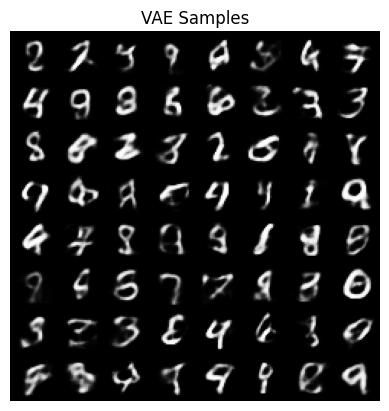

In [ ]:
with torch.no_grad():

    z = torch.randn(64, 20).to(device)

    samples = vae.decode(z).view(-1, 1, 28, 28)

    grid = make_grid(samples, 8)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("VAE Samples")
plt.axis("off")
plt.show()


## **Part 2. DCGAN (Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0, 표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - 마지막 layer에서 sigmoid를 통해 Real/Fake 확률값 출력


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [6]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [7]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64, 1, 3, 1, 1, bias=False)

    def forward(self, z):
        x = F.relu(self.bn1(self.tconv1(z)))   # 🤔 빈칸을 채워주세요 (Generator의 입력)
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))
        x = torch.tanh(self.tconv4(x))   # 🤔 빈칸을 채워주세요 (마지막 layer 통과)
        return x


**✍️ 위에서 채운 `Generator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* `Generator`의 `forward` 함수는 무작위 노이즈 벡터인 z를 입력받아 점진적으로 해상도를 키워가며 최종적인 가짜 이미지를 만들어내는 역할을 한다. 코드를 보면 처음 들어온 잠재 벡터가 여러 층의 전치 합성곱 레이어 tconv를 연속해서 거치며 이미지의 형태를 갖춰가는 구조로 되어있다. 이때 각 층을 통과할 때마다 배치 정규화(bn)를 적용해 학습 과정을 안정시키고 ReLU 활성화 함수를 더해 모델이 이미지의 복잡한 특징을 잘 학습하도록 한다. 마지막 레이어인 tconv4를 통과한 직후에는 tanh 함수를 적용하는데, 이는 생성된 가짜 이미지의 픽셀 값 범위를 -1에서 1 사이로 일정하게 규격화하여 최종 결과물을 출력하기 위함이다.


In [8]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 1, 3, 1, 0, bias=False)

    def forward(self, x):

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)   # 🤔 빈칸을 채워주세요 (conv3 + bn3 통과)
        x = torch.sigmoid(self.conv4(x))

        return x.view(-1, 1).squeeze(1)


**✍️ 위에서 채운 `Discriminator.forward` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* `Discriminator`의 `forward` 함수는 입력된 이미지가 실제 데이터인지 아니면 생성자가 만든 가짜 데이터인지 확률적으로 판별하는 역할을 한다. 코드를 살펴보면 처음 들어온 이미지 데이터가 총 4단계의 합성곱 레이어(conv)를 연속적으로 통과하면서 점차 크기가 압축되고 핵심 특징만 추출되도록 구성되어 있다. 각 층을 지날 때마다 `leaky_relu`를 사용해 뉴런이 죽는 것을 방지하고, 배치 정규화 bn을 적용해 학습 과정을 안정적으로 유지한다. 모든 특징 추출이 끝난 마지막 레이어인 conv4 직후에는 sigmoid 함수를 통과시켜 최종 결과값을 0에서 1 사이의 확률값으로 변환해준다. 마지막으로 view와 squeeze 함수를 사용해 이후 손실(Loss)을 계산하기 편하도록 텐서의 불필요한 차원을 없애고 1차원 형태의 배열로 펴서 출력하게 한다.


In [9]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(), 0.0002, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), 0.0002, betas=(0.5, 0.999))


In [ ]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x, _ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)

        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0), latent_size, 1, 1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # ========== Train Generator ==========

        loss_G = criterion(D(fake_img), real)  # 🤔 빈칸을 채워주세요 (Generator는 D가 fake_img를 무엇으로 착각하길 원할까요?)

        optG.zero_grad()
        loss_G.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += loss_G.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {train_lossD:.4f} | Loss G: {train_lossG:.4f}")


Epoch [1/15] Loss D: 0.7291 | Loss G: 1.8504
Epoch [2/15] Loss D: 0.8492 | Loss G: 1.5358
Epoch [3/15] Loss D: 0.9203 | Loss G: 1.4201
Epoch [4/15] Loss D: 0.9590 | Loss G: 1.3974
Epoch [5/15] Loss D: 0.9542 | Loss G: 1.3990
Epoch [6/15] Loss D: 0.9623 | Loss G: 1.4173
Epoch [7/15] Loss D: 0.9502 | Loss G: 1.4485
Epoch [8/15] Loss D: 0.9524 | Loss G: 1.4624
Epoch [9/15] Loss D: 0.9453 | Loss G: 1.4761
Epoch [10/15] Loss D: 0.9379 | Loss G: 1.4880
Epoch [11/15] Loss D: 0.9084 | Loss G: 1.5650
Epoch [12/15] Loss D: 0.9135 | Loss G: 1.5427
Epoch [13/15] Loss D: 0.8902 | Loss G: 1.6030
Epoch [14/15] Loss D: 0.8909 | Loss G: 1.6038
Epoch [15/15] Loss D: 0.8822 | Loss G: 1.6181


**✍️ 위에서 채운  코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 위 코드는 GAN의 생성자와 판별자를 번갈아가며 경쟁적으로 학습시키는 전체 훈련 루프이다. 먼저 판별자를 훈련할 때는 실제 이미지에 진짜(1) 라벨을, 생성자가 만든 가짜 이미지에는 가짜(0) 라벨을 부여해 각각의 오차를 더한 뒤 판별자만 똑똑해지도록 가중치를 업데이트한다. 이때 `detach()` 함수를 사용해 역전파되는 기울기가 생성자까지 넘어가지 않도록 연결을 끊어준다. 이어서 생성자를 훈련할 때는 판별자를 속이는 것이 목표이므로, 가짜 이미지를 판별자에 넣었을 때 정답이 진짜(1)가 되도록 오차를 계산하고 이번에는 생성자의 가중치만 업데이트한다. 이렇게 매 배치마다 판별자와 생성자가 서로를 이기기 위해 각자의 가중치를 번갈아 조절하며, 에포크가 끝날 때마다 평균 손실 값을 계산하고 출력하여 두 네트워크의 학습 진행 상황을 객관적인 지표로 확인한다.


**DCGAN Sampling 시각화**

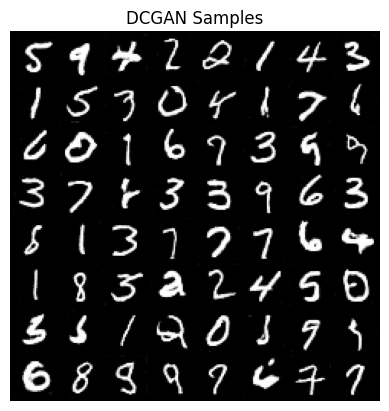

In [ ]:
G.eval()

with torch.no_grad():

    z = torch.randn(64, latent_size, 1, 1).to(device)

    samples = G(z)

grid = make_grid(samples, 8, normalize=True)

plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()


## **🙋 [GAN] Question 1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* 두 모델이 이미지를 학습하고 평가하는 목적(Loss)의 구조적 차이 때문이다.
* 1. **VAE의 픽셀 평균화(흐릿한 이유)**: VAE는 원본 이미지와 자신이 만들어낸 이미지 간의 픽셀 단위 오차(Reconstruction Loss)를 줄이도록 학습한다. 위치가 조금만 어긋나도 오차가 크게 계산되기 때문에 모델은 틀리지 않기 위해 불확실한 경계선 픽셀들을 전부 검은색과 흰색의 중간 값인 회색으로 채워버린다. 이에 따라 경계선이 뭉개지고 흐릿한 결과물이 나온다.
* 2. **DCGAN의 적대적 학습(선명한 이유)**: 반면 DCGAN은 픽셀 단위의 오차를 계산하지 않는다. 오직 판별자(Discriminator)가 이 이미지를 진짜/가짜로 보느냐만 따진다. 조금이라도 흐릿하거나 뭉개진 이미지는 판별자에게 즉시 가짜로 걸리지기 때문에 생성자(Generator)는 픽셀의 정확도보다 뚜렷한 윤곽선과 높은 대비를 가진 선명한 이미지를 만들어내게 된다.


## **🙋 [GAN] Question 2**
GAN 학습 과정에서 Generator와 Discriminator 중 한쪽이 너무 빨리 강해지면 어떤 문제가 발생할 수 있는지, Mode collapse 또는 Vanishing gradient 개념을 활용하여 설명해주세요.

* 누가 먼저 강해지느냐에 따라 두 가지 문제가 발생할 수 있다.

* 1. **판별자가 너무 빨리 강해질 경우(기울기 소실)**: 판별자가 너무 똑똑해져서 초반부터 진짜와 가짜를 완벽하게 구별하게 되면 생성자에게 주는 오차(Loss) 피드백이 무의미해진다. 수학적으로는 오차 역전파 과정에서 생성자에게 전달되어야 할 기울기가 '0'에 수렴하는 현상이다. 이렇게 되면 생성자는 자신이 만든 이미지를 어느 방향으로 어떻게 고쳐야 판별자를 속일 수 있는지 단서를 얻지 못해 가중치 업데이트가 멈추고 학습이 그대로 종료되어 버린다.

* 2. **생성자가 너무 빨리 강해질 경우(모드 붕괴)**: 생성자가 판별자의 허점을 일찍 파악해버리면 데이터의 다양성을 포기하는 문제가 생긴다. 판별자를 확실히 속일 수 있는 필승 패턴(예를 들어 완벽하게 그려진 숫자 1)만을 발견한 뒤 다른 숫자를 그리는 모험은 멈추고 오직 그 숫자 1만 무한 반복해서 찍어낸다. 이에 따라 출력물으 다양성(Mode)이 붕괴되어 쓸모없는 모델이 된다.


## **Part 3. Diffusion Model (DDPM) 원리 구현**

- **Forward process**: 원본 이미지 $x_0$에 $t$번에 걸쳐 점진적으로 Gaussian noise를 주입하여 $x_t$를 만드는 과정. Closed-form으로 한 번에 임의의 t 시점 노이즈 이미지를 계산할 수 있음
  $$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)$$

- **Reverse process**: 노이즈 $x_t$로부터 노이즈 $\epsilon$을 예측하는 신경망(주로 U-Net)을 학습시켜, $x_T$(순수 노이즈)부터 $x_0$까지 역으로 복원

- **손실함수의 단순화**: DDPM 논문의 핵심 기여 중 하나로, 복잡한 분포 비교 대신 신경망이 예측한 노이즈와 실제 주입된 노이즈 사이의 단순 MSE Loss만으로 학습이 가능함
  $$L_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[\, \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \,\right]$$

이번 파트에서는 **forward process와 손실함수, 노이즈 예측 네트워크의 핵심 구조를 직접 코드로 구현**하며 원리를 이해합니다. 다만 DDPM은 실제로는 대규모 U-Net을 오랜 시간 학습해야 제대로 된 이미지가 나오기 때문에, 짧은 실습 환경(Colab)에서 처음부터 학습시키기엔 한계가 있습니다. 그래서 우리가 구현한 것과 동일한 원리로 학습된 **Hugging Face의 사전학습 MNIST DDPM 모델**을 불러와 실제 reverse process 결과를 확인해봅니다.


In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)


### **Noise Schedule 정의**
$\beta_t$를 선형으로 증가시키며, $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$ 를 미리 계산해둡니다.


In [11]:
T = 1000  # DDPM 논문 기준 총 diffusion step 수

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)


def forward_diffusion(x0, t):
    """x0(원본 이미지)에 timestep t만큼의 노이즈를 주입해 x_t를 반환"""
    noise = torch.randn_like(x0)

    sqrt_ac = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_omac = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    x_t = sqrt_ac * x0 + sqrt_omac * noise   # 🤔 빈칸을 채워주세요 (forward process 수식)

    return x_t, noise


**✍️ 위에서 채운 `forward_diffusion` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* `forward_diffusion` 함수는 원본 이미지(x0)에 특정 시점(t)에 해당하는 만큼의 노이즈를 한 번에 씌워주는 역할을 한다. 코드를 보면 가장 먼저 `torch.randn_like'를 사용해 원본과 동일한 크기의 무작위 가우시안 노이즈를 생성한다. DDPM 모델은 1단계부터 노이즈를 순차적으로 더하는 비효율적인 방식 대신 수학적 공식을 통해 t시점의 상태를 단번에 계산할 수 있다. 이를 위해 사전에 정의해둔 누적 변수 배열에서 원본 데이터가 유지될 비율(sqrt_ac)과 노이즈가 섞일 비율(sqrt_omac)을 해당 시점 t에 맞게 뽑아낸 뒤, 이미지 텐서와 연산이 가능하도록 차원을 변환해준다. 마지막으로 원본 이미지와 앞서 만든 노이즈에 각각의 비율을 곱하고 더해주면 중간 과정을 생략하고도 t시점까지 노이즈가 누적된 결과물 x_t가 즉시 계산되어 반환된다.


**Forward process 시각화**: t가 커질수록 이미지가 점점 순수 노이즈에 가까워지는 것을 확인해봅시다.

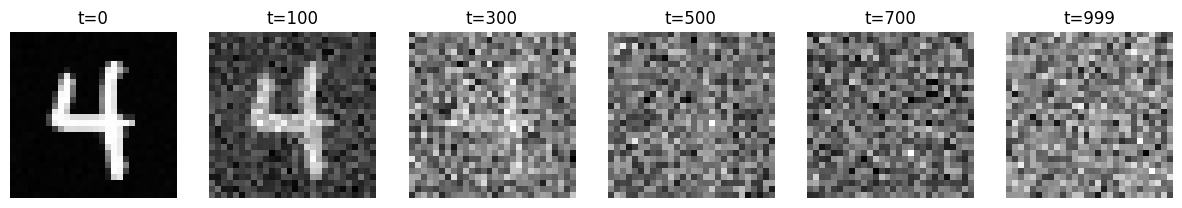

In [ ]:
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)

timesteps_to_show = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

for i, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val]).to(device)
    x_t, _ = forward_diffusion(x0, t)
    axes[i].imshow(x_t[0, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"t={t_val}")
    axes[i].axis("off")

plt.show()


### **U-Net 기반 노이즈 예측 네트워크**
DDPM은 노이즈가 섞인 이미지 $x_t$와 timestep $t$를 입력받아 주입된 노이즈 $\epsilon$을 예측하는 신경망을 사용합니다. 아래는 skip connection을 포함한 축소된 U-Net 구조입니다. Downsampling에서 저장해둔 feature map을 Upsampling 단계에서 다시 이어붙여(concat), 공간 정보 손실을 줄이는 것이 핵심입니다.


In [12]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


class SimpleUNet(nn.Module):

    def __init__(self, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Downsampling
        self.down1 = nn.Conv2d(1, 64, 3, padding=1)                    # 28 -> 28
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)        # 28 -> 14
        self.down3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)       # 14 -> 7

        self.time_proj = nn.Linear(time_dim, 256)

        # Bottleneck
        self.bottleneck = nn.Conv2d(256, 256, 3, padding=1)            # 7 -> 7

        # Upsampling (skip connection으로 채널이 2배가 됨)
        self.up1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)   # 7 -> 14
        self.up_conv1 = nn.Conv2d(128 + 128, 128, 3, padding=1)           # skip(h2) concat

        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)    # 14 -> 28
        self.up_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)              # skip(h1) concat

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Downsampling (skip connection용으로 각 단계 출력을 저장)
        h1 = F.relu(self.down1(x))      # (B, 64, 28, 28)
        h2 = F.relu(self.down2(h1))     # (B, 128, 14, 14)
        h3 = F.relu(self.down3(h2))     # (B, 256, 7, 7)

        # timestep embedding을 bottleneck 채널에 더해줌
        t_proj = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h3 = h3 + t_proj   # 🤔 빈칸을 채워주세요 (h3에 timestep 정보를 더해주려면?)

        h3 = F.relu(self.bottleneck(h3))

        # Upsampling + skip connection (concat)
        u1 = F.relu(self.up1(h3))                      # (B, 128, 14, 14)
        u1 = torch.cat([u1, h2], dim=1)                 # (B, 256, 14, 14)
        u1 = F.relu(self.up_conv1(u1))                  # (B, 128, 14, 14)

        u2 = F.relu(self.up2(u1))                       # (B, 64, 28, 28)
        u2 = torch.cat([u2, h1], dim=1)                  # (B, 128, 28, 28)
        u2 = F.relu(self.up_conv2(u2))                   # (B, 64, 28, 28)

        out = self.out(u2)

        return out


**✍️ 위에서 채운 `SimpleUNet.forward`의 timestep 결합 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 위 코드는 U-Net이 현재 몇 번째 단계(timestep)의 노이즈를 제거해야 하는지 알려주는 역할을 한다. 디퓨전 모델은 단계별로 섞여 있는 노이즈의 강도가 다르기 때문에 모델에게 지금이 어느 시점인지 반드시 알려주어야 정확한 복원이 가능하다. 코드 구성을 보면, 먼저 1차원 배열 형태인 시간 정보 `t_emb`를 선형 레이어 `time_proj`에 통과시켜 이미지 특징 맵 `h3`과 동일한 256개의 채널 수로 맞춘다. 그다음 `unsqueeze` 함수를 두 번 연속 사용해 가로세로 차원을 생성하여 `[배치, 채널, 1, 1]` 형태의 4차원 텐서(t_proj)로 팽창시킨다. 이렇게 뼈대를 맞춘 `t_proj`를 `h3`에 더해주면 파이토치의 브로드캐스팅(Broadcasting) 기능이 자동으로 작동한다. 즉 `1*1` 크기였던 시간 정보가 `7*7` 크기인 `h3`의 모든 픽셀 위치에 덧씌워진다. 결과적으로 모델은 이미지의 시각적인 공간 특징과 현재 시점의 노이즈 상태까지 하나의 텐서 안에서 동시에 파악하고 학습할 수 있게 된다.


### **DDPM Loss**
예측한 노이즈와 실제 주입한 노이즈 사이의 MSE Loss입니다.


In [13]:
def ddpm_loss(model, x0):
    B = x0.size(0)

    t = torch.randint(0, T, (B,), device=device).long()

    x_t, noise = forward_diffusion(x0, t)

    predicted_noise = model(x_t, t)

    loss = F.mse_loss(predicted_noise, noise)   # 🤔 빈칸을 채워주세요 (실제 노이즈 vs 예측 노이즈)

    return loss


**✍️ 위에서 채운 `ddpm_loss` 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* `ddpm_loss` 함수는 디퓨전 모델이 노이즈를 얼마나 정확히 짚어내는지 평가해 훈련 방향을 제시하는 역할을 한다.
* 코드가 작동하는 순서를 보자. 가장 먼저 배치 내의 각 원본 이미지(`x0`)마다 0부터 전체 확산 단계(`T`) 사이의 무작위 시점(`t`)을 하나씩 뽑아낸다. 그런 다음 `forward_diffusion` 함수를통해 원본 이미지에 해당 시점에 맞는 정확한 양의 실제 정답 노이즈(`noise`)를 씌워 훼손된 이미지(`x_t`)를 만들어낸다. 이제 이 훼손된 이미지와 현재 시점 정보를 U-Net 모델에 통과시켜, 모델이 이미지에 낀 노이즈를 스스로 추론(`predicted_noise`)하도록 한다. 마지막으로 모델이 예측해낸 노이즈와 애초에 주입했던 실제 노이즈 간의 차이를 평균 제곱 오차(`mse_loss`)로 계산해 반환하며, 모델은 최종적으로 이 오차 값을 최소화하는 방향으로 학습하게 된다.


## **🙋 [Diffusion] Question 1**
DDPM은 왜 원본 이미지 $x_0$를 직접 예측하지 않고, 이미지에 주입된 노이즈 $\epsilon$을 예측하도록 학습할까요?

* 학습의 수학적 안정성과 난이도 최적화 때문이다.

* 1. **타겟의 일관성과 안정성**: 네트워크가 예측해야 할 노이즈 $\epsilon$은 항상 평균이 0, 분산이 1인 표준 정규분포 N(0,I)를 따른다. 반면, 원본이미지 x_0는 데이터셋에 따라 픽셀 분포가 매우 복잡하고 불규칙하다. 딥러닝 모델 입장에서는 복잡하고 변동성이 큰 분포를 맞추는 것보다, 항상 일정한 형태를 유지하는 정규분포를 타겟으로 삼아 오차를 계산하는 것이 훨씬 안정적이다.

* 2. **극단적 시점에서의 예측 난이도**: 노이즈가 거의 100% 덮여 있는 확산 후반부(예: t=999)를 생각해보자. 형체를 알아볼 수 없는 노이즈 덩어리(x_i)를 입력으로 주고 한 번에 완벽한 원본(x_0)을 예측하라고 하면, 오차가 너무 커서 모델의 가중치 업데이트가 요동치게 된다. 하지만 현재 텐서에 섞여 있는 노이즈 형태를 맞추라고 하면, 타겟의 스케일이 일정하게 유지되므로 학습 과정에서 기울기가 폭주하지 않는다.

* 3. **노이즈를 찾는 것은 원본으로 가는 방향을 찾는 것**: 가우시안 노이즈 $\epsilon$을 예측하는 목적 함수는 데이터 확률 분포의 기울기를 나타내는 스코어 함수를 예측하는 것과 동일한 의미를 가진다. 즉 노이즈를 덜어내는 방향을 찾는 것이 진짜 데이터가 존재하는 확률적 밀도가 가장 높은 곳을 향하는 기울기가 된다.


In [14]:
unet = SimpleUNet().to(device)

# 참고: 위에서 구현한 forward_diffusion / SimpleUNet / ddpm_loss가
# DDPM 학습의 핵심 원리 전부입니다. 다만 실제로 눈에 보이는 숫자 이미지를
# 생성할 수준까지 학습시키려면 훨씬 더 큰 모델과 긴 학습 시간이 필요합니다.
# 아래에서는 동일한 원리로 이미 충분히 학습된 사전학습 모델을 불러와
# reverse process 결과를 직접 확인해봅니다.


### **사전학습된 DDPM으로 Reverse Process 결과 확인**

Hugging Face에는 우리가 위에서 구현한 것과 동일한 원리(forward process, 노이즈 예측 U-Net, MSE loss)로 MNIST를 학습시킨 DDPM 모델이 공개되어 있습니다. `DDPMPipeline`을 불러와 실제 reverse process가 어떻게 노이즈에서 숫자 이미지를 만들어내는지 확인해봅시다.


In [15]:
!pip install -q diffusers transformers accelerate safetensors

model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

FrozenDict({'num_train_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'beta_schedule': 'squaredcos_cap_v2', 'trained_betas': None, 'variance_type': 'fixed_small', 'clip_sample': True, 'prediction_type': 'epsilon', 'thresholding': False, 'dynamic_thresholding_ratio': 0.995, 'clip_sample_range': 1.0, 'sample_max_value': 1.0, 'timestep_spacing': 'leading', 'steps_offset': 0, 'rescale_betas_zero_snr': False, '_class_name': 'DDPMScheduler', '_diffusers_version': '0.27.2'})


  0%|          | 0/200 [00:00<?, ?it/s]

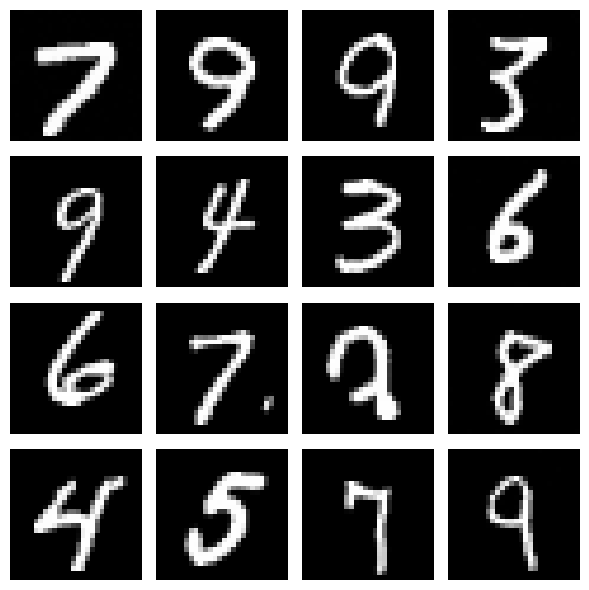

In [16]:
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = DDPMPipeline.from_pretrained(
    "nathanReitinger/MNIST-diffusion"
).to(device)

# Scheduler 설정 확인
print(pipe.scheduler.config)

# Reverse process
images = pipe(
    batch_size=16,
    num_inference_steps=200
).images

# 결과 확인
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for ax, image in zip(axes.flatten(), images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 별도 question!
결과가 이상하게 나와서 당황하셨죠?
왜 ddpm은 앞의 vae와 gan과 다르게 일관적이지 않고 어떤건 바르게 어떤 건 완전 악필이 쓴 것처럼 나오는 걸까요?

- 세 가지 모델의 이론적 차이를 비교해보자.

1. **VAE: 평균화 (Mean-seeking)**
VAE는 오차를 최소화하기 위해 여러 데이터의 특징을 평균 내어 학습한다. 데이터셋에 악필(이상치)이 섞여 있어도 이를 정상적인 글씨들과 섞어 중간값을 찾아내므로, 결과물들의 형태가 일정하고 균일하게 나오지만 디테일이 뭉개진다.

2. **GAN: 모드 집중 (Mode-seeking)**
GAN은 판별자를 속일 확률이 가장 높은 특정 데이터 영역(Mode)에만 집중적으로 수렴하는 경향이 있다. 학습 과정에서 이상치나 특이한 형태를 생성하는 것은 판별자에게 걸릴 위험이 크므로, 모델은 이를 배제하고 가장 뚜렷하고 정형화된 형태(명필)만 선택적으로 생성하게 된다.

3. **DDPM: 전체 분포 보존 (Distribution-covering)**
반면 DDPM은 수학적으로 원본 데이터셋 전체의 확률 분포를 손실 없이 그대로 모사하도록 설계되었다. 따라서 데이터셋 내부에 존재하는 악필 같은 '낮은 빈도의 이상치(Outlier)' 영역까지 배제하지 않고 전부 학습 공간에 포함시킨다.

여기에 더해 DDPM은 무작위 가우시안 노이즈에서 복원을 시작한다. 처음 뽑힌 노이즈의 좌표가 어디냐에 따라 정갈한 글씨 영역으로 수렴할 수도 있고, 악필 영역으로 수렴할 수도 있다. 즉 결과물이 들쭉날쭉한 것은 DDPM이 원본 데이터셋에 내재된 극단적인 다양성을 가장 왜곡 없이 온전히 반영하고 있기 때문이다.

## **🙋 [Diffusion] Question 2**
VAE, GAN, Diffusion 세 모델을 **학습 안정성**, **생성 품질**, **추론(샘플링) 속도** 세 가지 관점에서 비교해주세요.(이론적 비교)

1. **학습 안정성**

- **VAE(높음)**: 원본 데이터와 복원된 데이터 간의 차이(ELBO 최적화)를 최소화하는 단일 목적 함수 사용. 목표가 명확하므로 가중치 업데이트가 일정하고 수렴이 매우 안정적.
- **GAN(낮음)**: 생성자와 판별자가 경쟁하는 구조(Min-Max Game).두 네트워크의 학습 속도 균형이 조금만 어긋나도 기울기 소실이나 모드 붕괴 문제가 발생해 학습 난이도가 높음.
- **Diffusion(높음)**: 매 단계마다 정규 분포를 따르는 노이즈($\epsilon$)를 타겟으로 삼아 평균제곱오차(MSE)만 계산. 오차 공간의 형태가 일정하게 유지되므로 기울기 폭주나 붕괴 없이 학습이 안정적으로 진행.

2. **생성 품질**

- **VAE(낮음)**: 픽셀 단위의 오차를 피하기 위해 데이터 확률 분포의 평균값을 추정. 경계선이 뭉개지며 전반적으로 흐릿한(Blurry) 이미지 생성.

- **GAN(높음)**: 판별자의 검증을 통과하기 위해 픽셀 간의 대비가 뚜렷하고 선명한(Sharp) 이미지를 강제적으로 만듦. 다만, 판별자를 속이기 쉬운 특정 데이터 영역(Mode)에만 집중하므로 출력물의 다양성은 떨어짐.

- **Diffusion (매우 높음)**: 수학적으로 원본 데이터셋의 전체 확률 분포를 훼손 없이 모사. VAE의 한계인 흐릿함과 GAN의 한계인 획일화(모드 붕괴)를 모두 극복하여 디테일과 데이터 다양성을 동시에 보여줌.

3. **추론 속도 (Inference Speed)**

- **VAE & GAN (빠름)**: 생성자의 신경망을 한 번만 통과시키면(Single Forward Pass) 즉시 완성된 이미지 출력. 실시간 처리가 가능할 정도로 연산 빠름.

- **Diffusion (느림)**: 무작위 노이즈에서 출발해 U-Net 모델을 수십에서 수백 번 반복적으로 통과하며(Iterative Denoising) 노이즈를 깎아내야 함. 구조적으로 연산량이 가장 방대하며 이미지를 샘플링하는 속도가 가장 느림.



## **Part 4. Hugging Face `diffusers`로 사전학습 Diffusion 모델 실습**

Part 3에서 우리는 DDPM의 핵심 원리(forward process, 노이즈 예측 U-Net, MSE loss)를 직접 코드로 구현하고, MNIST 전용 사전학습 모델로 그 결과를 확인해봤습니다. 이번에는 훨씬 크고 복잡한 U-Net을 방대한 이미지-텍스트 데이터로 학습시킨 모델을 다뤄봅니다. 대표적으로 **Stable Diffusion**은 발표자료에서 다룬 것처럼 VAE + Diffusion(Latent Diffusion) + Cross-Attention 기반 Text Conditioning 구조를 가지고 있습니다.

Hugging Face의 `diffusers` 라이브러리를 사용하면 이런 사전학습 모델을 몇 줄의 코드로 불러와 사용할 수 있습니다. Colab에서는 **런타임 유형을 GPU로 설정**한 후 진행해주세요. (런타임 → 런타임 유형 변경 → T4 GPU)


In [17]:
!pip install -q diffusers transformers accelerate


### **4-1. Text-to-Image: Stable Diffusion**

프롬프트를 입력하면 그에 맞는 이미지를 생성해주는 `StableDiffusionPipeline`을 사용해봅니다. 내부적으로는 텍스트 프롬프트를 CLIP text encoder로 임베딩하고, 이를 조건으로 latent space에서 diffusion(denoising)을 수행한 뒤, VAE decoder로 pixel space 이미지를 복원합니다. (발표자료 33p의 Stable Diffusion 구조 참고)


In [18]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

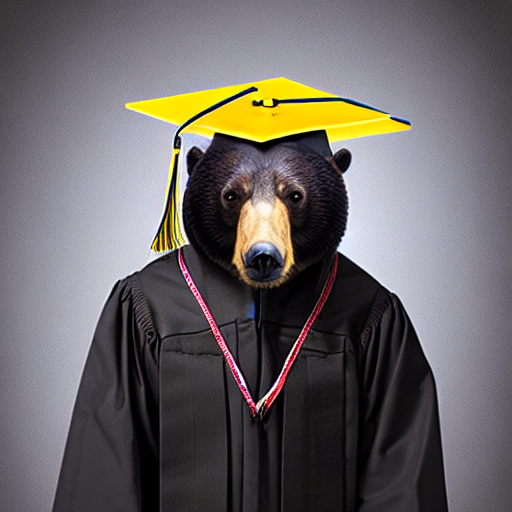

In [19]:
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"   # 🤔 원하는 프롬프트로 자유롭게 바꿔보세요

image = pipe(
    prompt,
    num_inference_steps=30,   # 🤔 빈칸을 채워주세요 (몇 step 만에 denoising을 마칠지, 예: 25~50)
    guidance_scale=7.5
).images[0]

image


**✍️ 위에서 채운 `num_inference_steps` 코드가 어떤 기능을 하고, 이 값이 커지거나 작아지면 결과가 어떻게 달라지는지 간단히 설명해주세요.**

* `num_inference_steps`는 모델이 100% 무작위 노이즈에서 출발해 최종 이미지를 완성하기까지 거치는 노이즈 제거(Denoising) 연산의 총 반복 횟수를 결정하는 파라미터이다.

* 디퓨전 모델은 점진적으로 노이즈를 깎아내는데 이 값을 조절하면 수학적 정교함과 연산 속도 간의 트레이드오프(Trade-off)가 발생하여 결과물이 달라진다.

* **값이 커질 때 (예: 50 이상)**:
노이즈를 더 잘게 쪼개어 아주 미세한 간격으로 정교하게 제거한다. 생성 궤적을 추정하는 수학적 오차가 줄어들어 이미지의 퀄리티와 디테일이 높아진다. 하지만 설정한 횟수만큼 무거운 모델(U-Net)을 반복적으로 통과해야 하므로, 이미지를 생성하는 데 걸리는 추론 시간이 정비례하여 느려진다.

* **값이 작아질 때 (예: 10 이하)**:
한 번의 스텝에서 덜어내는 노이즈의 양이 많아진다. 중간 연산 과정을 건너뛰는 만큼 궤적 추정 오차가 누적되어, 디테일이 뭉개지거나 형체를 알아보기 힘든 노이즈 낀 이미지가 출력된다. 대신 반복 연산이 적으므로 생성 속도는 매우 빠르다.

* 결론적으로 이 파라미터는 '이미지의 퀄리티를 높이기 위해 연산 시간을 얼마나 더 투자할 것인가'를 직관적으로 통제하는 기능을 수행한다.


## **🙋 [Hugging Face] Question 1**
위 코드의 `guidance_scale` 파라미터는 발표자료의 **Classifier-free guidance(CFG)** 개념과 관련이 있습니다. `guidance_scale` 값을 낮추거나(예: 1.0) 높이면(예: 15.0) 생성 결과가 각각 어떻게 달라질지 예상해보고, 실제로 두 값으로 각각 이미지를 생성해 비교해주세요.

* CFG 스케일은 모델이 사용자의 텍스트 지시(프롬프트)를 얼마나 강력하게 따를지 강제하는 수치이다.

* 수치가 너무 낮으면 모델이 지시를 따르지 않고, 너무 높으면 텍스트에 억지로 맞추려다 이미지의 구조가 무너진다. 실무에서 7.0 ~ 8.5 사이의 값을 가장 대중적으로 사용하는 이유는 그 값이 수학적 최적점이기 때문이다. 구체적인 예시로 보면 다음과 같다.

1. **guidance_scale = 1.0 (텍스트 무시)**

이 설정에서는 모델이 프롬프트를 거의 무시하고, 자신이 가진 데이터 분포(사전 지식)에만 의존해 자유롭게 이미지를 생성한다.

- 예상 결과: 이미지 자체의 자연스러움이나 털의 질감은 부드럽고 훌륭할 수 있으나, 정작 지시했던 '졸업식 모자'나 '스튜디오 조명'은 누락될 확률이 높다. 평범하고 자연스러운 야생 곰 사진이 출력될 가능성이 크다.

2. **guidance_scale = 15.0 (텍스트 집착)**

반대로 수치가 너무 높으면, 모델이 프롬프트의 모든 단어에 극단적으로 집착하여 어떻게든 조건에 맞는 픽셀을 맞추려고 시도한다.

- 예상 결과: 졸업식 모자는 곰 머리에 선명하게 씌워지겠지만, 강제성이 너무 커진 나머지 부작용이 발생할 수 있다. 색상 대비가 비정상적으로 높아져 이미지가 타버리고(Color Saturation), 형태가 기괴하게 일그러지는 아티팩트가 생길 수 있다.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

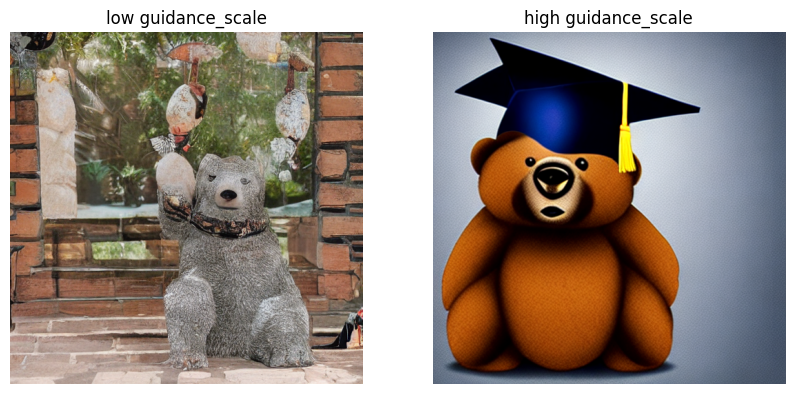

In [20]:
# 🤔 guidance_scale을 다르게 주어 두 이미지를 생성하고 비교해주세요
prompt = "a photo of a bear wearing a graduation cap, studio lighting, high quality"

image_low_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=1.0).images[0]   # 🤔 빈칸을 채워주세요
image_high_cfg = pipe(prompt, num_inference_steps=30, guidance_scale=15.0).images[0]  # 🤔 빈칸을 채워주세요

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_low_cfg)
axes[0].set_title("low guidance_scale")
axes[0].axis("off")
axes[1].imshow(image_high_cfg)
axes[1].set_title("high guidance_scale")
axes[1].axis("off")
plt.show()


**✍️ 위에서 채운 `guidance_scale` 비교 코드가 어떤 기능을 하고, 코드적으로 어떻게 구성되어 있는지 간단히 설명해주세요.**

* 위 코드는 동일한 프롬프트를 주고 `guidance_scale` 설정값만 극단적으로 다르게 했을 때 생성된 두 결과물의 차이를 비교하는 스크립트이다. 코드의 핵심 구성은 다음과 같다.

1. **이미지 독립 생성(`pipe` 호출)**

동일한 파이프라인을 두 번 실행한다. 첫 번째는 스케일을 1.0(낮음)으로, 두 번째는 15.0(높음)으로 지정한다. 이때 파이프라인이 반환하는 복잡한 결과물 객체에서 순수 이미지 데이터만 뽑아내기 위해 끝에 `.images[0]`을 붙여 각각의 변수에 저장한다.

2. **시각화 레이아웃 배치 (`matplotlib` 활용)**

`plt.subplots(1, 2)`를 호출해 이미지를 가로로 나란히 넣을 2칸짜리 캔버스를 만든다. 왼쪽 공간(`axes[0]`)에는 스케일이 낮은 이미지를, 오른쪽 공간(`axes[1]`)에는 높은 이미지를 맵핑(`imshow`)한다. 격자나 축 눈금을 `axis("off")`로 깔끔하게 지운 뒤, `plt.show()`로 화면에 출력하여 스케일 차이에 따른 형태 붕괴나 텍스트 무시 현상을 직관적으로 비교할 수 있게 한다.


### **4-2. Sampler(Scheduler) 교체해보기**

발표자료 33p에서 언급했듯 Stable Diffusion은 하나로 고정된 모델이 아니라, denoising에 사용하는 sampler(scheduler)를 자유롭게 교체할 수 있는 구조입니다. 기본 스케줄러 대신 DDIM 스케줄러로 교체하여 더 적은 step으로도 이미지를 생성해봅니다.


  0%|          | 0/20 [00:00<?, ?it/s]

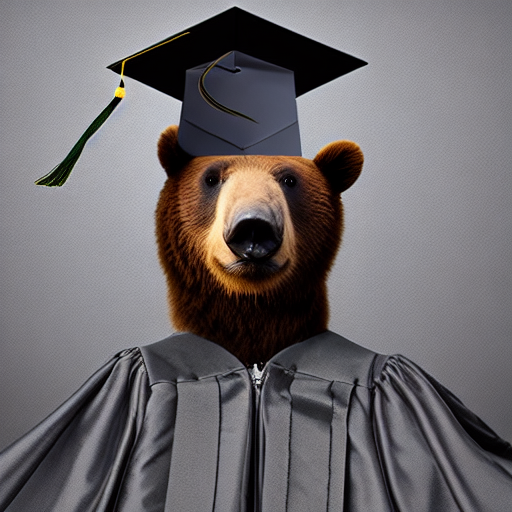

In [21]:
from diffusers import DDIMScheduler

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

image_ddim = pipe(
    prompt,
    num_inference_steps=20,  # DDPM보다 훨씬 적은 step
    guidance_scale=7.5
).images[0]

image_ddim


## **🙋 [Hugging Face] Question 2**
DDIM 스케줄러가 기본 스케줄러보다 적은 step으로도 그럴듯한 이미지를 생성할 수 있는 이유를 Part 3에서 다룬 DDPM의 reverse process와 비교하여 설명해주세요.

* **DDPM (마르코프 체인)**: 복원 과정이 바로 직전 시점($x_{t-1}$)에만 수학적으로 종속되어 있다. 무조건 한 칸씩 움직여야 하므로, 중간 단계를 임의로 건너뛰면 통계적 오차가 폭발해 이미지가 붕괴됩니다.

* **DDIM (결정론적 점프)**: 이 제약을 없애고 수식을 비마르코프(Non-Markovian) 방식으로 재정의했다. 현재 노이즈 상태($x_t$)에서 100% 맑은 원본($x_0$)을 한 번에 추정한 뒤, 이를 나침반 삼아 10~20단계씩 건너뛴다.

* 결론적으로 DDPM이 1,000개의 계단을 빠짐없이 한 칸씩 내려와야 하는 연산 구조라면, DDIM은 도착지의 좌표를 미리 계산해 수십 칸씩 뛰어내릴 수 있도록 한 것이다.


## **🙋 [Hugging Face] Question 3**
직접 해보기 + 허깅 페이스와 인사하기

허깅페이스의 모델 api 활용하기/space에서 모델 3개 이상 활용해보기
둘 중 하나를 택해서 실행하고 간단하게 써본 경험을 공유해주세요!

[예시 노션 링크](https://app.notion.com/p/Hugging-face-3a059e60d52d80f49489f7a3c3ef6648?source=copy_link)

[★Hugging Face Space 활용 탐구 보고서](https://app.notion.com/p/Hugging-Face-Space-3d10743c054580308a9aca4c47d49658?source=copy_link)


## 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 기울기 폭주의 의미, gpu 실행 에러 해결

- **AI가 이 실험에는 틀린 답을 준 사례** -

- **실제 대화 내역** 붙여넣기:

(1)

```
> 나: 기울기 폭주의 의미가 무엇인가요?
```

```
< Gemini: 기울기 소실(Vanishing Gradient)과 정확히 반대되는 현상입니다.

기울기 소실이 오차 역전파 과정에서 미분값이 0에 수렴해 학습이 멈추는 것이라면, 기울기 폭주(Exploding Gradient)는 반대로 곱해지는 미분값들이 1보다 커서 연쇄 법칙(Chain Rule)에 의해 눈덩이처럼 기하급수적으로 커져버리는 현상입니다.

발생 원리와 문제점

원인: 딥러닝은 출력층에서 입력층 방향으로 기울기를 연속해서 곱하며 가중치를 업데이트합니다. 이때 층이 깊은 상태에서 미분값이 조금만 커도, 계속 곱해지면서 최종 기울기가 비정상적으로 팽창합니다.

증상: 가중치 업데이트 보폭이 너무 커져서 모델이 최적점을 찾지 못하고 이리저리 널뛰기를 합니다. 결국 손실(Loss) 값이 NaN(Not a Number)이나 무한대(Infinity)로 치솟으며 학습 자체가 완전히 붕괴됩니다.

비유: 자동차로 섬세하게 엑셀을 밟아 주차(최적화)를 해야 하는데, 실수로 엑셀을 끝까지 밟아버려 벽을 뚫고 날아가는 상황과 같습니다.

이런 폭주 현상을 방지하기 위해, 기울기 값이 특정 한계치를 넘지 못하도록 강제로 잘라버리는 그래디언트 클리핑(Gradient Clipping) 기법을 주로 사용합니다.
```

(2)

```
> 나: 다음의 에러가 발생한 이유는 무엇인가요?

---------------------------------------------------------------------------AssertionError Traceback (most recent call last)/tmp/ipykernel_1955/3853545023.py in <cell line: 0>() 8 torch_dtype=torch.float16 9 )---> 10 pipe = pipe.to("cuda")

8 frames

/usr/local/lib/python3.13/dist-packages/torch/cuda/__init__.py in _lazy_init() 469 ) 470 if not hasattr(torch._C, "_cuda_getDeviceCount"):--> 471 raise AssertionError("Torch not compiled with CUDA enabled") 472 if _cudart is None: 473 raise AssertionError(AssertionError: Torch not compiled with CUDA enabled
```
```
< Gemini: 발생한 Torch not compiled with CUDA enabled 에러는 현재 환경에 설치된 PyTorch가 GPU(CUDA)를 지원하지 않는 CPU 전용 버전이거나, 시스템에서 GPU를 제대로 할당받지 못했을 때 발생합니다.

코드 실행 경로(/tmp/ipykernel...)를 보아 쥬피터 노트북 계열을 사용 중이신 것 같은데, 환경에 따라 아래 방법을 시도해 보십시오.

1. 구글 코랩(Colab)을 사용 중이신 경우
가장 흔한 원인으로, 런타임에 GPU 할당이 안 되어 있을 확률이 높습니다.

상단 메뉴에서 런타임 > 런타임 유형 변경을 클릭합니다.

하드웨어 가속기를 GPU(T4 등)로 변경하고 저장합니다.

셀을 다시 실행해 봅니다.

2. 로컬 PC나 개인 서버를 사용 중이신 경우
GPU 지원용 PyTorch를 명시적으로 다시 설치해야 합니다. 터미널을 열고 아래 명령어를 순서대로 실행해 주십시오.

Bash
# 기존 PyTorch 패키지 삭제
pip uninstall torch torchvision torchaudio -y

# CUDA 지원 버전으로 재설치 (CUDA 12.1 기준)
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
현재 코랩 환경에서 작업 중이신가요, 아니면 로컬 PC 환경이신가요? 로컬 환경이시라면 현재 장착된 그래픽 카드(GPU) 모델을 알려주시면 버전에 맞는 더 정확한 해결책을 찾아드리겠습니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? GPU로 런타임 할당 후 맨 위 셀부터 다시 실행(오래 걸리는 에포크 실험 제외)


수고하셨습니다 ☺️